In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/home/joana/projects/python-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


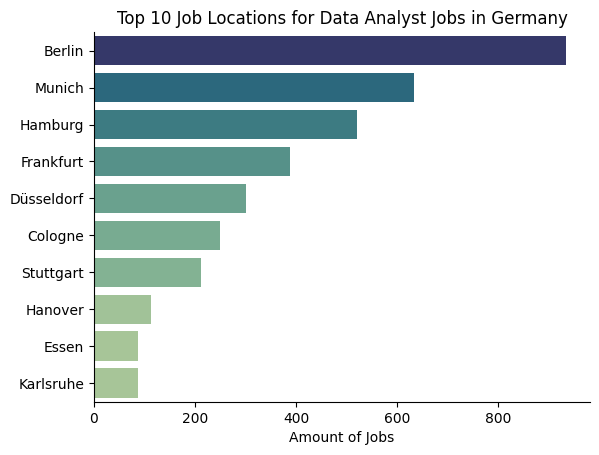

In [3]:
#filter for data analyst roles in GER
df_DA_GER = df[(df['job_country'] == 'Germany') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_GER['job_location_clean'] = (df_DA_GER['job_location'].str.replace(', Germany', '', regex=False))
#top 10 locations
exclude = ['Germany', 'Anywhere', 'Remote', 'Worldwide']
df_plot = df_DA_GER[~df_DA_GER['job_location_clean'].isin(exclude)]['job_location_clean'].value_counts().head(10).to_frame()

#add remote insight if wanted
#remote_count = df_DA_GER['job_location'].isin(['Anywhere', 'Remote', 'Worldwide']).sum()
#df_plot.loc['Remote'] = remote_count

sns.barplot(data=df_plot, x='count', y='job_location_clean', hue='count', palette='crest', legend=False)
sns.set_theme(style='ticks')
sns.despine()
plt.title('Top 10 Job Locations for Data Analyst Jobs in Germany')
plt.xlabel('Amount of Jobs')
plt.ylabel('')
plt.show()


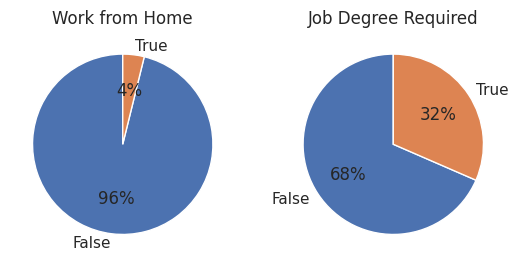

In [4]:
fig,ax = plt.subplots(1, 2)

dict_columns = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Required',
}

for i, (column, title) in enumerate(dict_columns.items()):
    ax[i].pie(df_DA_GER[column].value_counts(), startangle=90, autopct='%1.0f%%', labels=['False', 'True'])
    ax[i].set_title(title)


plt.show()

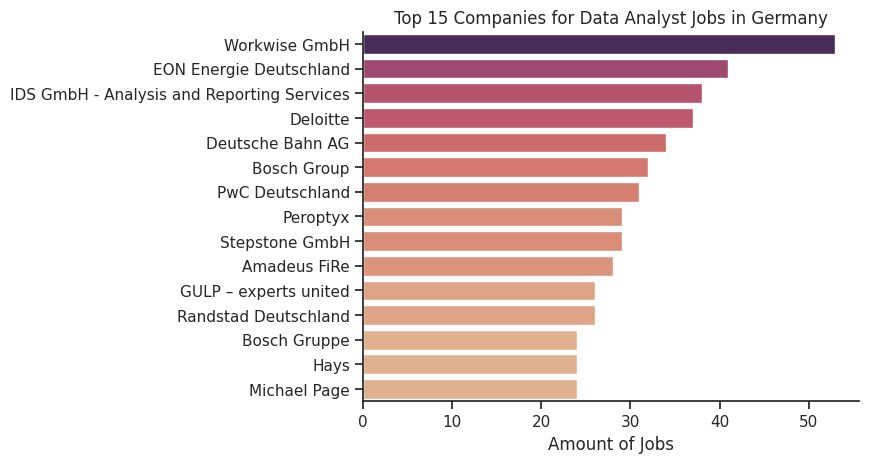

In [5]:
df_plot = df_DA_GER['company_name'].value_counts().head(15).to_frame()
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='flare', legend=False)
sns.set_theme(style='ticks')
sns.despine()
plt.title('Top 15 Companies for Data Analyst Jobs in Germany')
plt.xlabel('Amount of Jobs')
plt.ylabel('')
plt.show()

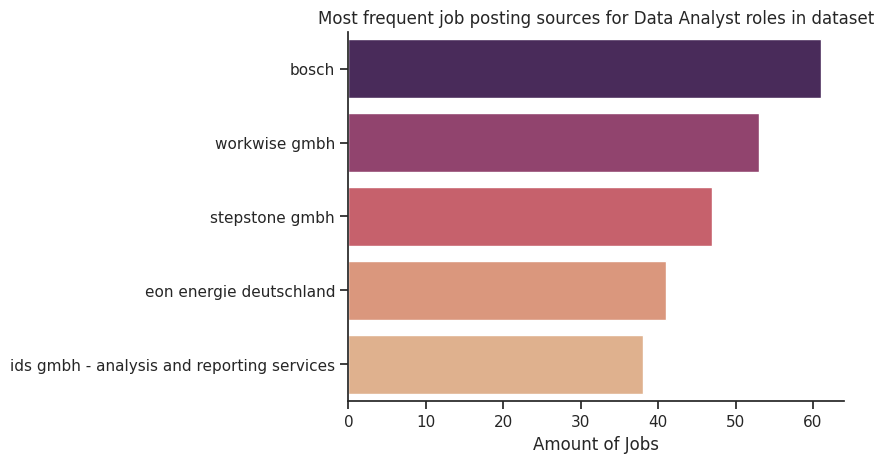

In [7]:
#clean Bosch naming
df_DA_GER['company_clean'] = (
    df_DA_GER['company_name']
    .str.lower()
    .str.strip()
)
df_DA_GER['company_clean'] = df_DA_GER['company_clean'].replace({
    'bosch gruppe': 'bosch',
    'bosch group': 'bosch',
    'robert bosch gmbh': 'bosch'
})

df_plot = df_DA_GER['company_clean'].value_counts().head(5).to_frame()
sns.barplot(data=df_plot, x='count', y='company_clean', hue='count', palette='flare', legend=False)
sns.set_theme(style='ticks')
sns.despine()
plt.title('Most frequent job posting sources for Data Analyst roles in dataset')
plt.xlabel('Amount of Jobs')
plt.ylabel('')
plt.show()